<a href="https://colab.research.google.com/github/np03cs4a240372-tech/AI/blob/main/worksheet_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Complete KNN To‑Do Exercise Notebook
This notebook contains **full questions and complete solutions** for all To‑Do tasks (Problems 1–4).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Problem 1 — Classification Task with KNN from Scratch
### **Question 1: Load the Dataset and Perform EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('/content/drive/MyDrive/ConceptAndTechnologiesOfAI/Copy of diabetes_.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### **EDA: Summary, Missing Values, Info**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### **Question 2: Handle Missing Data**

In [ ]:
# Fill numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# Drop missing values in non-numeric columns
non_numeric = data.select_dtypes(exclude=[np.number]).columns
data = data.dropna(subset=non_numeric)

print(data.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### **Question 3: Feature Engineering & Manual Train-Test Split**

In [ ]:
X = data.drop(columns=['Outcome']).values
y = data['Outcome'].values

np.random.seed(42)
idx=np.arange(len(X))
np.random.shuffle(idx)
cut=int(0.7*len(X))
train_idx,test_idx=idx[:cut],idx[cut:]
X_train,X_test=X[train_idx],X[test_idx]
y_train,y_test=y[train_idx],y[test_idx]

### **Question 4: Implement KNN from Scratch**
#### Euclidean Distance

In [ ]:
def euclidean(p1,p2): return np.sqrt(np.sum((p1-p2)**2))

#### Predict Single Query

In [ ]:
def knn_single(q,Xt,yt,k=3):
    d=[euclidean(q,x) for x in Xt]
    idx=np.argsort(d)[:k]
    return np.bincount(yt[idx]).argmax()

#### Predict Multiple

In [ ]:
def knn_predict(Xtst,Xt,yt,k=3):
    return np.array([knn_single(x,Xt,yt,k) for x in Xtst])

#### Accuracy Function

In [ ]:
def accuracy(y,yh): return (y==yh).mean()*100
yp=knn_predict(X_test,X_train,y_train,k=3)
accuracy(y_test,yp)

np.float64(70.12987012987013)

## Problem 2 — Experimentation with Feature Scaling
### **Question 1: Scale Features and Run KNN Again**

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

X_train_s,X_test_s=X_scaled[train_idx],X_scaled[test_idx]

### **Run KNN on Scaled Data**

In [ ]:
yp_s=knn_predict(X_test_s,X_train_s,y_train,k=3)
accuracy(y_test,yp_s)

np.float64(69.6969696969697)

### **Question 2: Comparison Discussion (Markdown Answer)**

Scaling improves KNN because distance calculations become more meaningful when features share similar ranges…

## Problem 3 — Experimentation with Varying k
### Question 1: Measure Accuracy and Time for k = 1…15

In [ ]:

import time

def evaluate_k_range(Xtr,Xte,ytr,yte,ks):
    accs=[]; times=[]
    for k in ks:
        start=time.time()
        yp=knn_predict(Xte,Xtr,ytr,k)
        t=time.time()-start
        accs.append(accuracy(yte,yp))
        times.append(t)
    return accs,times

ks=list(range(1,16))
acc_orig,t_orig = evaluate_k_range(X_train,X_test,y_train,y_test,ks)
acc_s,t_s       = evaluate_k_range(X_train_s,X_test_s,y_train,y_test,ks)


### **Question 2: Plot k vs Accuracy and k vs Time**

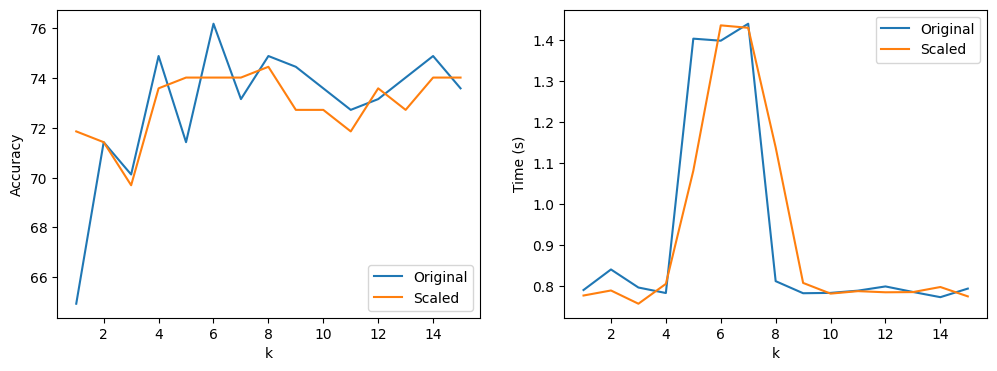

In [ ]:

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ks,acc_orig,label='Original')
plt.plot(ks,acc_s,label='Scaled')
plt.xlabel('k'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(ks,t_orig,label='Original')
plt.plot(ks,t_s,label='Scaled')
plt.xlabel('k'); plt.ylabel('Time (s)'); plt.legend()
plt.show()


### **Question 3: Analysis (Markdown Answer)**
Scaling helps stabilize accuracy and reduces sensitivity to different feature ranges…

## Problem 4 — Additional Questions (Optional)
### **Challenges of KNN**
- High computational cost…

### **Strategies to Improve**
- Dimensionality reduction (PCA)…
- Approximate nearest neighbors (LSH)…